# parameter recovery


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from matplotlib.ticker import FormatStrFormatter


In [2]:
outputFolderName = r"param_recovery_5_visualization"
inputFolderName = r"param_recovery_4_param_recovery"

if not os.path.exists(outputFolderName):
    os.makedirs(outputFolderName)

file_path = os.path.join(inputFolderName, "alpha_comparison.csv")
df = pd.read_csv(file_path)

In [3]:

fit_alpha_plus = df["fit_alpha_plus"].to_numpy(dtype=float)
fit_alpha_minus = df["fit_alpha_minus"].to_numpy(dtype=float)
sim_alpha_plus = df["sim_alpha_plus"].to_numpy(dtype=float)
sim_alpha_minus = df["sim_alpha_minus"].to_numpy(dtype=float)

def plot_with_recovery(ax, x, y, title):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)

    # remove NaNs
    mask_valid = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask_valid]
    y = y[mask_valid]

    if len(x) < 2:
        ax.text(0.5, 0.5, "Not enough valid points", ha="center", va="center")
        ax.set_title(title)
        return

    # scatter
    ax.scatter(x, y, alpha=0.5, edgecolors='none', s=30)

    # axis limits
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    padding = 0.02

    # identity line
    ax.plot(
        [min_val - padding, max_val + padding],
        [min_val - padding, max_val + padding],
        '--',
        color='black',
        linewidth=0.8,
        label='Identity line'
    )

    # linear regression: simulated ~ fitted
    x_vals = x.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_vals, y)

    slope = model.coef_[0]
    intercept = model.intercept_

    # # regression line
    # x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
    # y_line = model.predict(x_line)
    # ax.plot(x_line, y_line, linewidth=1.2, label='Regression line')

    # Pearson correlation
    r, p = pearsonr(x, y)

    # RMSE relative to identity line
    rmse_identity = np.sqrt(np.mean((y - x) ** 2))

    # title
    ax.set_title(
        f"{title}\n"
        f"r = {r:.2f}, slope = {slope:.2f}, intercept = {intercept:.2f}\n"
        f"RMSE(identity) = {rmse_identity:.2f}"
    )

    ax.set_xlabel("Fitted")
    ax.set_ylabel("Simulated")

    ax.set_xlim(min_val - padding, max_val + padding)
    ax.set_ylim(min_val - padding, max_val + padding)

    ax.set_box_aspect(1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))



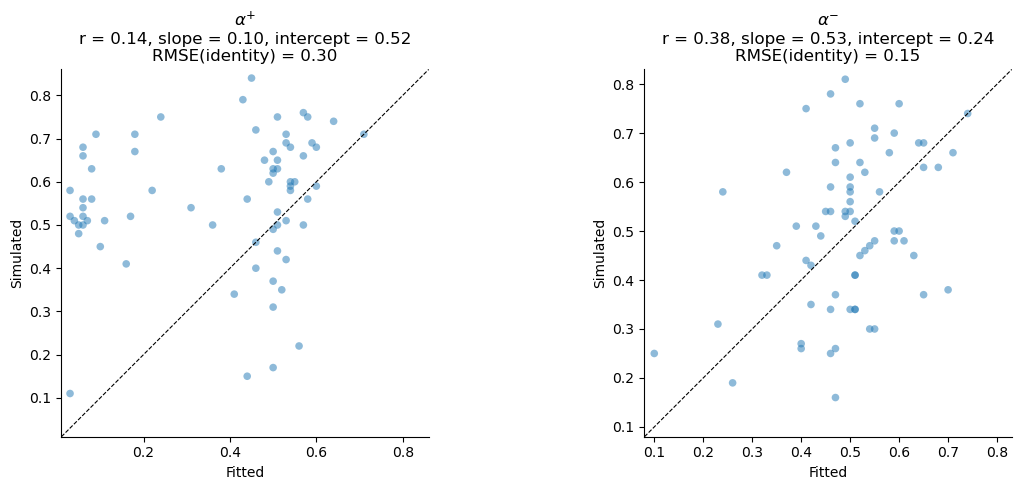

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_with_recovery(
    axes[0],
    fit_alpha_plus,
    sim_alpha_plus,
    r"$\alpha^{+}$"
)

plot_with_recovery(
    axes[1],
    fit_alpha_minus,
    sim_alpha_minus,
    r"$\alpha^{-}$"
)

plt.tight_layout()

# save
save_path = os.path.join(outputFolderName, "alpha_plus_minus_scatter.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()